# 🔍 Phase 4 (Bonus): Explainable AI with SHAP
Standard Feature Importance plots (like the one we used in XGBoost) only tell us *which* features the model used. They don't tell us *how* they affect the output. 

**SHAP (SHapley Additive exPlanations)** is the industry standard for Explainable AI. It tells us exactly how much a specific feature increased or decreased the ETA prediction.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
# 1. Load Data & Retrain XGBoost
df = pd.read_csv('../data/processed/engineered_running_times.csv')

X = df.drop(columns=['run_time_in_seconds'])
y = df['run_time_in_seconds']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [3]:
# 2. Initialize SHAP Explainer
# Calculating SHAP values is computationally heavy, so we'll use a random sample of 2,000 rows from the test set.
X_test_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)
print("SHAP values calculated.")

SHAP values calculated.


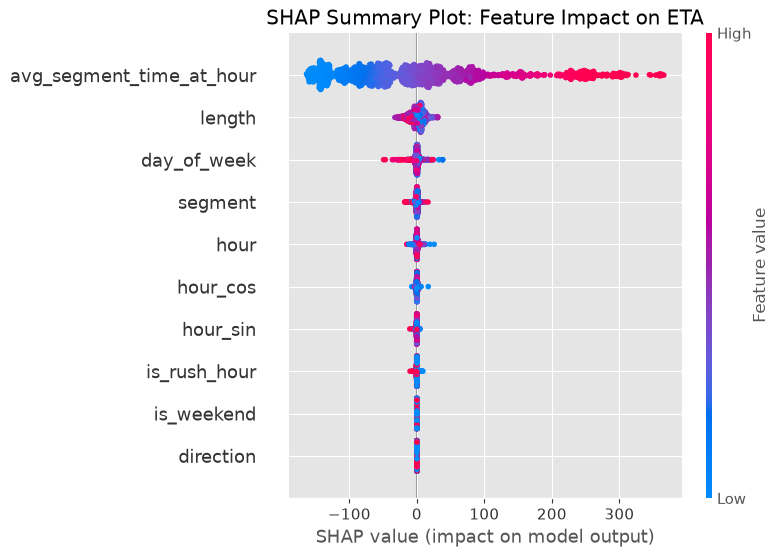

In [4]:
# 3. SHAP Summary Plot (The Gold Standard Plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot: Feature Impact on ETA')
plt.show()

# How to read this:
# - RED dots = High value of the feature (e.g., is_rush_hour = 1)
# - BLUE dots = Low value of the feature (e.g., is_rush_hour = 0)
# - If RED dots are on the RIGHT side of the center line, it means that feature INCREASES the ETA.
# - If RED dots are on the LEFT side, it means that feature DECREASES the ETA.

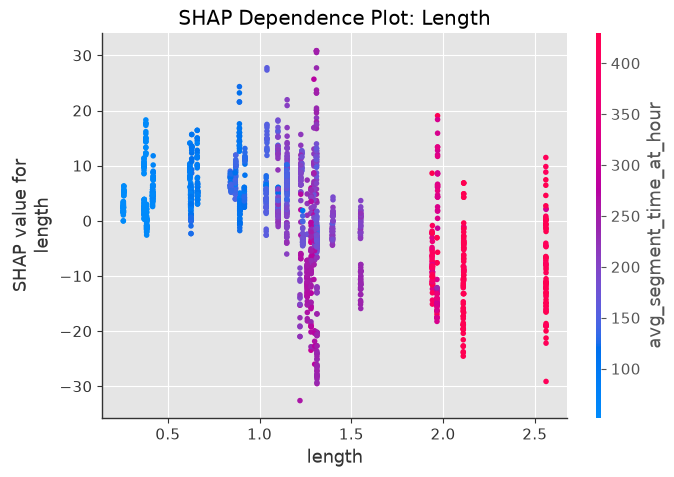

In [5]:
# 4. SHAP Dependence Plot (Optional but powerful)
# Let's look exactly how segment 'length' interacts with the ETA
shap.dependence_plot("length", shap_values, X_test_sample, show=False)
plt.title('SHAP Dependence Plot: Length')
plt.show()